# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Enesty Herdiyanti]
- **Email:** [enesty02@gmail.com]
- **ID Dicoding:** [enesty_herdiyanti]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk mana yang menghasilkan keuntungan tertinggi dan bagaimana perkembangan penjualan dari waktu ke waktu?
- Pertanyaan 2 : Apakah keterlambatan pengiriman memiliki pengaruh yang signifikan terhadap penilaian kepuasan pelanggan?

## Import Semua Packages/Library yang Digunakan

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [116]:
df_customers = pd.read_csv('customers_dataset.csv')
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [117]:
df_orders = pd.read_csv('orders_dataset.csv')
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [118]:
df_products = pd.read_csv('products_dataset.csv')
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [119]:
df_items = pd.read_csv('order_items_dataset.csv')
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [120]:
df_reviews = pd.read_csv('order_reviews_dataset.csv')
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
Dataset telah berhasil dimuat. Total tabel yang saling berkaitan yaitu ada 5. Selanjutnya melakukan assessing data untuk mengecek kualitas data.

### Assessing Data

Menilai tabel df_customers

In [121]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [122]:
print('Jumlah Duplikasi :', df_customers.duplicated().sum())
df_customers.describe()

Jumlah Duplikasi : 0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [123]:
print("ID Unik:", df_customers['customer_unique_id'].nunique())

ID Unik: 96096


Menilai tabel df_orders

In [124]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [125]:
print('Missing Value :', df_orders.isna().sum())
print('Jumlah Duplikasi :', df_orders.duplicated().sum())

Missing Value : order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Jumlah Duplikasi : 0


Menilai tabel df_products

In [126]:
df_products.info()
df_products.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [127]:
print('Jumlah Duplikasi :', df_products.duplicated().sum())
df_products.describe()

Jumlah Duplikasi : 0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


Menilai tabel df_items

In [128]:
df_items.info()
print('Jumlah Duplikasi :', df_items.duplicated().sum())
df_items.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
Jumlah Duplikasi : 0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Menilai tabel df_reviews

In [129]:
df_reviews.info()
df_reviews.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [130]:
print('Jumlah Duplikasi :', df_reviews.duplicated().sum())
df_reviews.describe()

Jumlah Duplikasi : 0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- Jumlah pada kolom customer_unique_id lebih sedikit dari total baris yang berarti terdapat pelanggan yang belanja berkali-kali
- Pada tabel df_orders, kolom order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date memiliki tipe data object dan kolom ini seharusnya bertipe data datetime
- Pada tabel df_product, kolom product_category_name, product_name_lenght, product_description_lenght, product_photos_qty terdapat 610 missing values dan kolom product_weight_g, product_length_cm, product_height_cm, product_width_cm terdapat 2 missing values.
- Pada tabel df_review, kolom review_creation_date dan review_answer_timestamp memiliki tipe data object dan kolom ini seharusnya bertipe data datetime. Pada kolom review_comment_title dan review_comment_message terdapat 87656 dan 58247 missing values, missing values ini kemungkinan banyaknya orang memberikan rating tapi malas menulis ulasan.

### Cleaning Data

Tabel df_customers

In [131]:
df_customers['customer_city'] = df_customers['customer_city'].str.lower().str.strip()
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Tabel df_orders

In [132]:
datetime_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for column in datetime_orders:
  df_orders[column] = pd.to_datetime(df_orders[column])
#Menghitung durasi pengiriman (hari)
df_orders['delivery_time_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days
df_orders.info()
df_orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time_days             96476 non-null  float64       
dtypes: datetime64[ns](5), float64(1), object(3)
memory usage: 6.8+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_time_days,2965


Tabel df_products

In [133]:
df_products['product_category_name'].fillna('others',inplace=True)
columns_product = ['product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for column in columns_product:
  df_products[column].fillna(0,inplace=True)
df_products.isna().sum()

/tmp/ipython-input-315/3268248850.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products['product_category_name'].fillna('others',inplace=True)
/tmp/ipython-input-315/3268248850.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


Tabel df_reviews

In [134]:
datetime_reviews = ['review_creation_date','review_answer_timestamp']
for column in datetime_reviews:
  df_reviews[column] = pd.to_datetime(df_reviews[column])
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [135]:
df_reviews['review_comment_title'].fillna('no title',inplace=True)
df_reviews['review_comment_message'].fillna('no message',inplace=True)
df_reviews.isna().sum()

/tmp/ipython-input-315/3069946973.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reviews['review_comment_title'].fillna('no title',inplace=True)
/tmp/ipython-input-315/3069946973.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


**Insight:**
- Missing value pada tabel orders tidak dihapus untuk mengetahui pesanan yang statusnya belum selesai(masih tahap pengiriman/ dibatalkan).
- delivery_time_days untuk mengetahui durasi pengiriman

## Exploratory Data Analysis (EDA)

### Explore df_customers

In [136]:
df_customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [137]:
print(df_customers.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10))


customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: customer_id, dtype: int64


In [138]:
print(df_customers.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False).head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: customer_id, dtype: int64


**Insight:**
- Pelanggan paling banyak berada di kota Sao Paulo
- Pelanggan paling banyak berada di state SP

### Explore df_orders

In [139]:
df_orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
count,99441,99441,99441,99441,99281,97658,96476,99441,96476.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,12.094086
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,6.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,15.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,209.000000


In [140]:
df_orders['delivery_time_days'].describe()

,delivery_time_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [141]:
df_orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [142]:
print(df_orders['order_purchase_timestamp'].dt.hour.value_counts().sort_index())

order_purchase_timestamp
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64


**Insight:**
- Rata-rata waktu pengiriman yaitu 12 hari
- Meskipun terjadi keterlambatan pengiriman, sebagian besar pesanan berstatus delivered/ terkirim kepada pelanggan

### Explore df_products

In [143]:
df_products.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32951,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
unique,32951,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,47.579527,757.213104,2.148463,2276.334315,30.813207,16.936633,23.195320
std,NaN,NaN,12.071951,637.745057,1.745732,4281.945502,16.915648,13.637779,12.080033
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,41.000000,326.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,584.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [144]:
df_products['product_category_name'].value_counts().head(10)

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


**Insight:**
- Produk cama_mesa_banho sebagai produk yang paling banyak diminati sehingga berpotensi menghasilkan pendapatan terbesar

### Explore df_items

In [145]:
df_items.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [146]:
df_items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [147]:
df_items['freight_value'].describe()

,freight_value
count,112650.000000
mean,19.990320
std,15.806405
min,0.000000
25%,13.080000
50%,16.260000
75%,21.150000
max,409.680000


**Insight:**
- Harga produk sebagian besar di kisaran 74, namun terdapat produk dengan harga yang sangat tinggi bernilai  6735.
- Dengan rata-rata ongkos kirim sebesar 19,99 akan dilakukan analisis untuk menilai apakah sebanding dengan kecepatan pengiriman yang diterima.

### Explore df_reviews

In [148]:
df_reviews.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,99224,99224,99224,99224
unique,98410,98673,NaN,4528,36160,NaN,NaN
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,no title,no message,NaN,NaN
freq,3,3,NaN,87656,58247,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,NaN,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,NaN,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,NaN,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,NaN,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,NaN,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35


In [149]:
df_reviews['review_score'].value_counts().sort_index(ascending=False)

,count
review_score,
5,57328
4,19142
3,8179
2,3151
1,11424


**Insight:**
- Nilai tingkat kepuasan pelanggan paling banyak berada dibintang 5. Namun, bintang  1 tidak bisa diabaikan karena mempunyai nilai yang cukup besar dan perlu dianalisis apakah penyebabnya berdasar kualitas produk atau pengiriman.

###Merge Data

Merge df_items & df_products

In [150]:
df_item_products = pd.merge(
    left=df_items,
    right=df_products,
    how='left',
    left_on='product_id',
    right_on='product_id'
)
df_item_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


**Insight:**
- Penggabungan data ini dilakukan untuk memetakan ID Produk ke nama kategori sehingga dapat mengetahui kategori produk yang paling menguntungkan

Merge df_item_products & df_orders

In [151]:
df_item_products_orders = pd.merge(
    left=df_item_products,
    right=df_orders,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
df_item_products_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0


**Insight:**
Penggabungan data ini dilakukan  untuk melihat perkembangan penjualan dari waktu ke waktu  dan mempersiapkan data durasi pengiriman untuk di analisis lebih lanjut.

Merge df_item_products_orders & df_reviews

In [152]:
df_all = pd.merge(
    left=df_item_products_orders,
    right=df_reviews,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
df_all.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,97ca439bc427b48bc1cd7177abe71365,5.0,no title,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,7b07bacd811c4117b742569b04ce3580,4.0,no title,no message,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,0c5b33dea94867d1ac402749e5438e8b,5.0,no title,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,f4028d019cb58564807486a6aaf33817,4.0,no title,no message,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,940144190dcba6351888cafa43f3a3a5,5.0,no title,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


**Insight:**
Penggabungan data ini menghasilkan dataset yang menghubungkan lamanya pengiriman dengan penilaian kepuasan pelanggan

In [153]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113314 non-null  object        
 1   order_item_id                  113314 non-null  int64         
 2   product_id                     113314 non-null  object        
 3   seller_id                      113314 non-null  object        
 4   shipping_limit_date            113314 non-null  object        
 5   price                          113314 non-null  float64       
 6   freight_value                  113314 non-null  float64       
 7   product_category_name          113314 non-null  object        
 8   product_name_lenght            113314 non-null  float64       
 9   product_description_lenght     113314 non-null  float64       
 10  product_photos_qty             113314 non-null  float64       
 11  

**Insight:**
df_all merupakan tabel yang menghubungkan antara informasi  produk, harga, waktu transaksi, performa pengiriman dan penilaian pelanggan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk mana yang menghasilkan keuntungan tertinggi dan bagaimana perkembangan penjualan dari waktu ke waktu?

Kategori produk yang menghasilkan keuntungan tertinggi

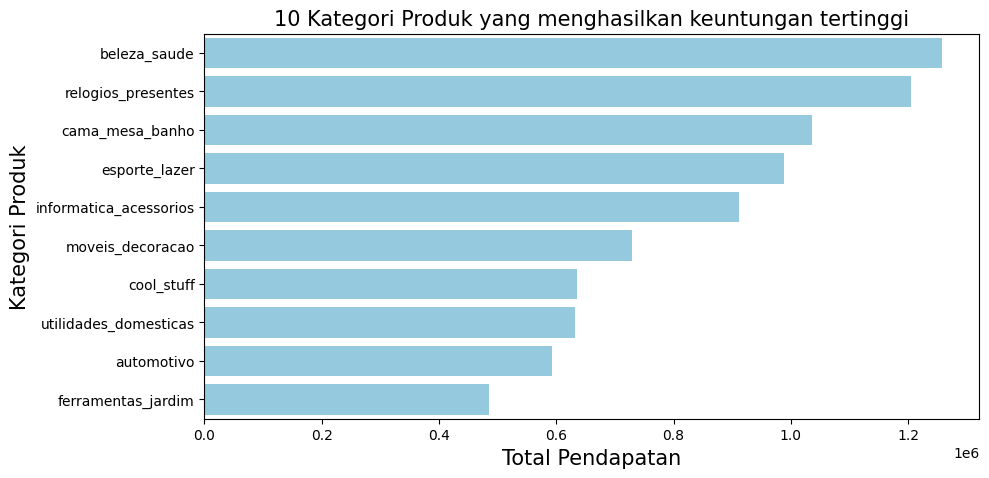

In [154]:
df_sum_order_items = df_item_products_orders.groupby(by='product_category_name').price.sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    x = 'price',
    y = 'product_category_name',
    data = df_sum_order_items.head(10),
    color = 'skyblue'
    )
plt.title('10 Kategori Produk yang menghasilkan keuntungan tertinggi',fontsize=15)
plt.xlabel('Total Pendapatan',fontsize=15)
plt.ylabel('Kategori Produk',fontsize=15)
plt.show()

Perkembangan penjualan

/tmp/ipython-input-315/2613152469.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_all.resample(rule='M', on='order_purchase_timestamp').agg({


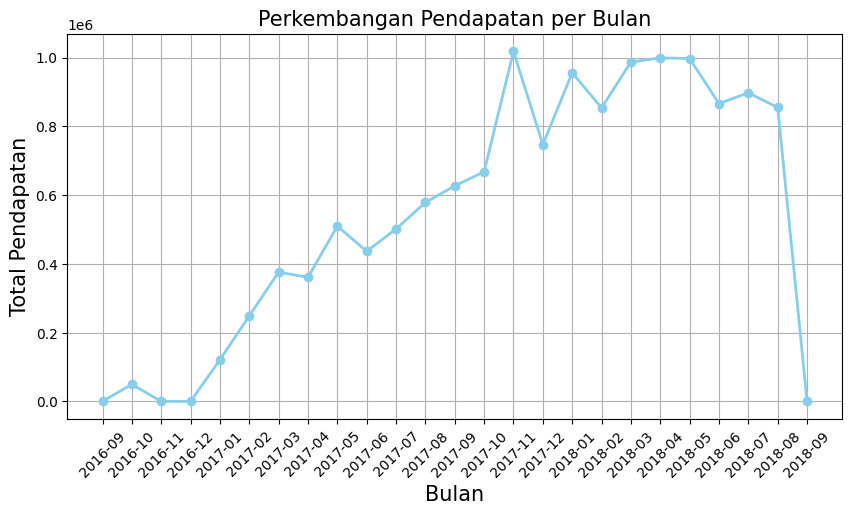

In [155]:
df_monthly = df_all.resample(rule='M', on='order_purchase_timestamp').agg({
    'order_id': 'nunique',
    'price': 'sum'})
df_monthly.index = df_monthly.index.strftime('%Y-%m')
df_monthly = df_monthly.reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_monthly['order_purchase_timestamp'], df_monthly['price'], marker='o', linewidth=2, color='skyblue')
plt.title('Perkembangan Pendapatan per Bulan', fontsize=15)
plt.xlabel('Bulan', fontsize=15)
plt.ylabel('Total Pendapatan', fontsize=15)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Pertanyaan 2: Apakah keterlambatan pengiriman memiliki pengaruh yang signifikan terhadap penilaian kepuasan pelanggan?

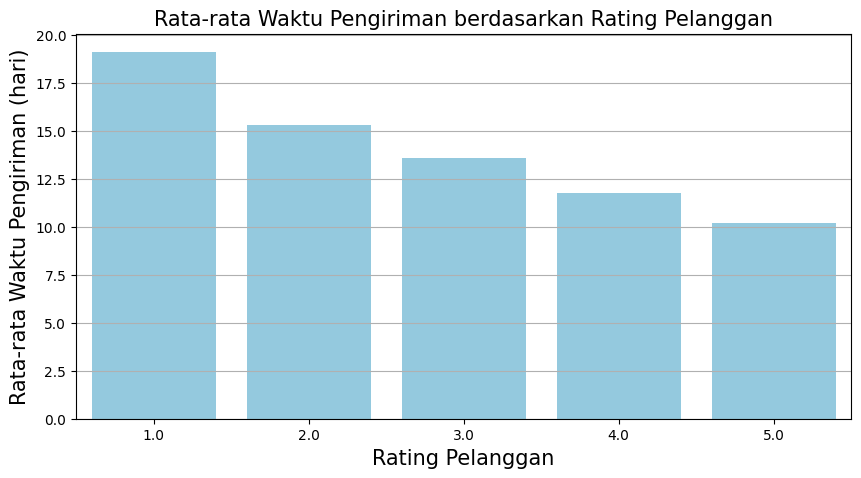

In [156]:
df_delivery_rating = df_all.groupby(by='review_score').delivery_time_days.mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x = 'review_score', y = 'delivery_time_days', data = df_delivery_rating, color = 'skyblue')
plt.title('Rata-rata Waktu Pengiriman berdasarkan Rating Pelanggan', fontsize=15)
plt.xlabel('Rating Pelanggan', fontsize=15)
plt.ylabel('Rata-rata Waktu Pengiriman (hari)', fontsize=15)
plt.grid(axis='y')
plt.show()

**Insight:**
- Kategori produk beleza_saude merupakan produk yang menghasilkan keuntungan tertinggi dikarenakan minat pelanggan pada kategori tersebut paling tinggi sehingga perusahaan dapat menambah stok produk atau melakukan campaign. Selain itu, perkembangan penjualan terus meningkat yang dapat dilihat pada awal tahun 2017 sampai pertengahan 2018 dan terdapat kenaikan tajam pada bulan November 2017 yang kemungkinan berkaitan dengan musim liburan
- Pelanggan dengan bintang 1 rata-rata menunggu pesanan selama hampir 19 hari, sedangkan pelanggan dengan bintang 5 lebih cepat menerima pesanan produk yaitu sekitar 10 hari. Hal ini menunjukkan bahwa durasi pengiriman dapat memengaruhi penilaian yang diberikan pelanggan.

## Analisis Lanjutan (Opsional)

RFM Analysis

In [157]:
df_rfm = df_all.groupby(by='customer_id', as_index=False).agg({'order_purchase_timestamp': 'max', 'order_id': 'nunique', 'price':'sum'})
df_rfm.columns = ['customer_id', 'max_order_purchase_timestamp', 'frequency', 'monetary']
df_rfm['max_order_purchase_timestamp'] = df_rfm['max_order_purchase_timestamp'].dt.date
recent_date = df_all['order_purchase_timestamp'].dt.date.max()
df_rfm['recency'] = df_rfm['max_order_purchase_timestamp'].apply(lambda x: (recent_date - x).days)
df_rfm.drop(columns='max_order_purchase_timestamp',axis=1, inplace=True)
df_rfm.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,293
1,000161a058600d5901f007fab4c27140,1,54.90,414
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,552
3,0002414f95344307404f0ace7a26f1d5,1,149.90,383
4,000379cdec625522490c315e70c7a9fb,1,93.00,154


/tmp/ipython-input-315/2023110835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='recency', x='customer_id', data=df_rfm.sort_values(by='recency', ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipython-input-315/2023110835.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='frequency', x='customer_id', data=df_rfm.sort_values(by='frequency', ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipython-input-315/2023110835.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='monetary', x='customer_id', data=df_rfm.s

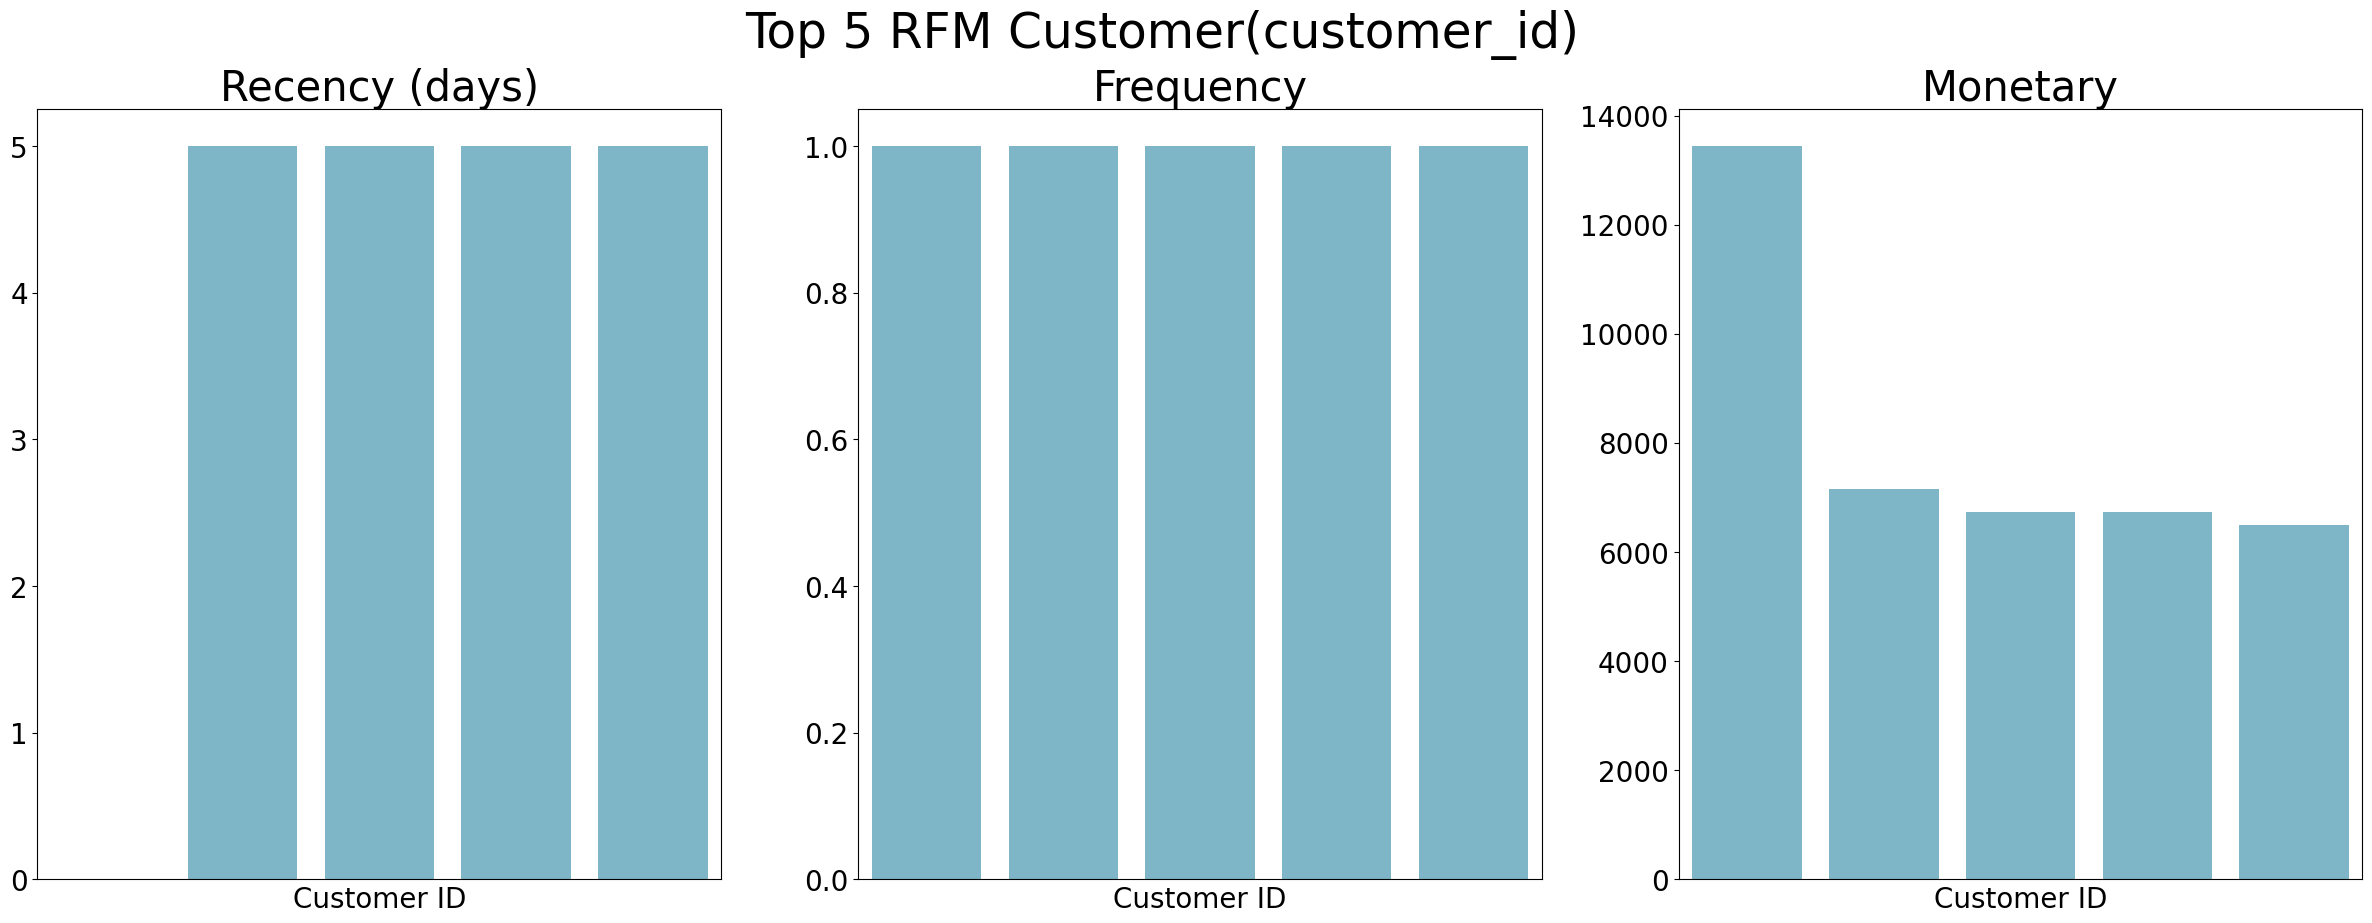

In [158]:
from matplotlib import axis
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30,10))
colors =  ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y='recency', x='customer_id', data=df_rfm.sort_values(by='recency', ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel('Customer ID', fontsize=20)
ax[0].set_title('Recency (days)', loc='center', fontsize=30)
ax[0].tick_params(axis='y', labelsize=20)
ax[0].set_xticks([])

sns.barplot(y='frequency', x='customer_id', data=df_rfm.sort_values(by='frequency', ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel('Customer ID', fontsize=20)
ax[1].set_title('Frequency', loc='center', fontsize=30)
ax[1].tick_params(axis='y', labelsize=20)
ax[1].set_xticks([])

sns.barplot(y='monetary', x='customer_id', data=df_rfm.sort_values(by='monetary', ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel('Customer ID', fontsize=20)
ax[2].set_title('Monetary', loc='center', fontsize=30)
ax[2].tick_params(axis='y', labelsize=20)
ax[2].set_xticks([])

plt.suptitle('Top 5 RFM Customer(customer_id)', fontsize=35)
plt.show()

**Insight:**
Analisis RFM diatas dapat melihat pelanggan terbaik memiliki nilai recency sangat rendah, frekuensi pembelian yang konsisten dan terdapat 1 pelanggan melakukan transaksi lebih dari 13000, jauh dari rata-rata pelanggan lainnya yang hanya sekitar 6000-7000

## Conclusion

- Conclution pertanyaan 1: Perkembangan penjualan terjadi pertumbuhan yang pesat pada tahun 2017 dengan puncak tertinggi di bulan November 2017. Agar perkembangan penjualan ini tetap bertahan, perusahaan disarankan untuk memperbanyak promosi dan stok produk di akhir tahun.
- Conclution pertanyaan 2: Durasi pengiriman memiliki pengaruh langsung terhadap penilaian kepuasan pelanggan. Perusahaan diharuskan menjaga bintang 5 dengan menetapkan standar pengiriman selama 10-12 hari.